# Military Aircraft Classification 
CNN, PyTorch native checkpoints

## Dependencies and Preparation

Install dependencies

In [1]:
%pip -q install requests matplotlib numpy "torch==2.10.0" torchvision pillow

Note: you may need to restart the kernel to use updated packages.


Download checkpoints and sample data

In [2]:
import io
import zipfile
from pathlib import Path

import requests

ZIPFILE_NAME = "TORCH_MilitaryAircraft"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / ZIPFILE_NAME
ZIP_URL = f"https://github.com/Authentrics-ai/authentrics-analysis-example-models/raw/refs/heads/main/{ZIPFILE_NAME}.zip"

if DATA_PATH.exists():
    print(f"Data already exists in {DATA_PATH}")

else:
    print(f"Downloading data from {ZIP_URL}...")
    response = requests.get(ZIP_URL)
    if response.status_code != 200:
        raise Exception(f"Failed to download file: {response.text}")

    print("Extracting the zip file...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if not DATA_PATH.is_dir():
        raise Exception(f"Failed to extract data: {DATA_PATH}")

    print(f"Data extracted to {DATA_PATH}")


Data already exists in data/TORCH_MilitaryAircraft


## Use a Model Adapter

Alternatively, you can subclass one and tailor it to your model, or implement a purely custom `ModelInterface` (see [docs](https://app.authentrics.ai/docs/user_guide#model-interface))

In [3]:
from pathlib import Path
from typing import Callable

import numpy as np
import torch
from torchvision.models import efficientnet_b3
from PIL import Image

classes = [
    "A10", "AH64", "B1", "B52", "C130",
    "C17", "C2", "EF2000", "F15", "F16",
    "F18", "F22", "F35", "F4", "J10",
    "J20", "JAS39", "Rafale", "US2", "V22",
]

Handle = torch.utils.hooks.RemovableHandle
Hook = Callable[[torch.nn.Module, object, object], None]

class MilAirModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.num_classes = len(classes)
        self.squeeze_edit_model = efficientnet_b3()

        self.squeeze_edit_model.classifier[1] = torch.nn.Linear(1536, 256)
        self.squeeze_edit_model.classifier.extend(
            [
                torch.nn.ReLU(),
                torch.nn.Dropout(p=0.45),
                torch.nn.Linear(256, self.num_classes),
            ]
        )

        for param in self.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.squeeze_edit_model(x)

def preprocess_image(image_file: Path) -> torch.Tensor:
    """Load and preprocess an image to CHW float32 tensor in [0, 1]."""
    image = Image.open(image_file).convert("RGB").resize((224, 224))
    arr = torch.from_numpy(np.array(image, dtype=np.float32)).permute(2, 0, 1)
    return arr / 255.0



In [4]:
from authentrics import AuthentricsSession, adapters, use_backend

use_backend("torch")

model = adapters.TorchAdapter(model=MilAirModel(), model_state_key="model")
model.model.cuda()
session = AuthentricsSession(model)

project = session.get_or_create_project(
    "MilAirClassificationExample-0630:TORCH",
    "Example project for TORCH-based CNN model",
)

checkpoint_paths = [DATA_PATH / f"checkpoint_{i}.pt" for i in range(1, 8)]
assert all(path.is_file() for path in checkpoint_paths), "All checkpoint files must exist!"

checkpoint_paths

[PosixPath('data/TORCH_MilitaryAircraft/checkpoint_1.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_2.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_3.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_4.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_5.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_6.pt'),
 PosixPath('data/TORCH_MilitaryAircraft/checkpoint_7.pt')]

## Static Analysis

In [5]:
result = session.static_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    parameter_names=[
        "squeeze_edit_model.features.0.0.weight",
        "squeeze_edit_model.classifier.1.weight",
        "squeeze_edit_model.classifier.4.weight",
        "squeeze_edit_model.classifier.4.bias",
    ],
)

result

<StaticAnalysisResult object num_params=4, summary_score=0.004124576>

In [6]:
print(result.to_dataframe())

                                        parameter_changes
squeeze_edit_model.classifier.1.weight           0.004061
squeeze_edit_model.classifier.4.bias             0.005540
squeeze_edit_model.classifier.4.weight           0.004951
squeeze_edit_model.features.0.0.weight           0.023210


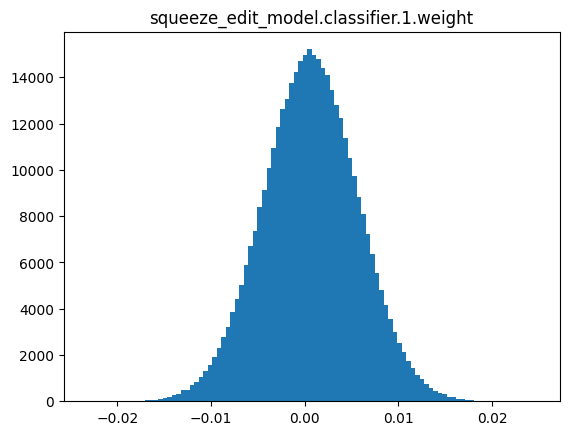

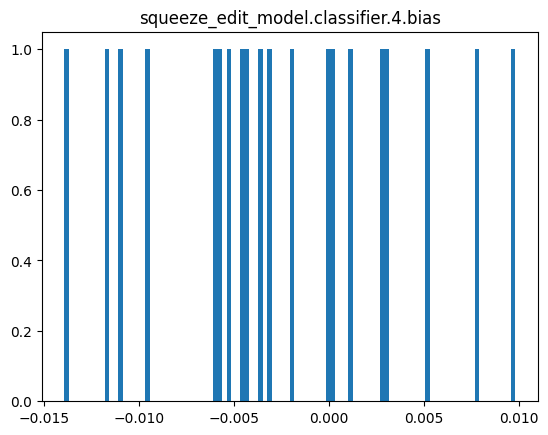

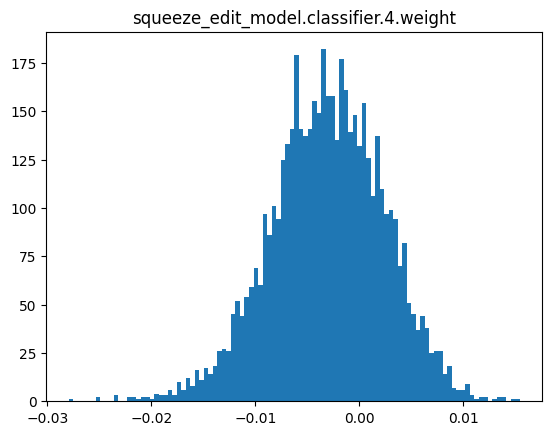

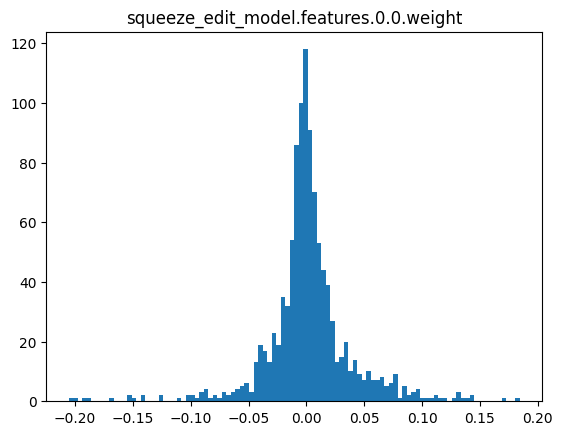

In [7]:
import matplotlib.pyplot as plt

for i, (param, hist) in enumerate(zip(result.parameter_names, result.parameter_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Activation Analysis

In [8]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = torch.stack([preprocess_image(image_path) for image_path in image_paths], dim=0)
print(input_data.shape)

[PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-2.jpg')]
torch.Size([7, 3, 224, 224])


In [9]:
result = session.activation_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    input_data.cuda(),
    layer_names=[
        "squeeze_edit_model.features.0.0",
        "squeeze_edit_model.features.1.0.block.0.0",
        "squeeze_edit_model.features.3.0.block.3.0",
        "squeeze_edit_model.features.6.0.block.3.0",
        "squeeze_edit_model.features.8.0",
        "squeeze_edit_model.classifier.4",
    ],
)

In [10]:
print(result.to_dataframe())


                                           cosine_similarities  l2_distances
squeeze_edit_model.classifier.4                       0.565877      8.453850
squeeze_edit_model.features.0.0                       0.986388    140.499863
squeeze_edit_model.features.1.0.block.0.0             0.994919    534.262085
squeeze_edit_model.features.3.0.block.3.0             0.984117    599.912415
squeeze_edit_model.features.6.0.block.3.0             0.949505    200.851898
squeeze_edit_model.features.8.0                       0.545710    514.989502


## Correlation Analysis

In [11]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = torch.stack([preprocess_image(image_path) for image_path in image_paths], dim=0)
print(input_data.shape)

[PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-2.jpg')]
torch.Size([7, 3, 224, 224])


In [12]:
result = session.correlation_analysis(
    project.id,
    checkpoint_paths[1],
    input_data.cuda(),
    layer_names=[
        "squeeze_edit_model.features.0.0",
        "squeeze_edit_model.features.1.0.block.0.0",
        "squeeze_edit_model.features.3.0.block.3.0",
        "squeeze_edit_model.features.6.0.block.3.0",
        "squeeze_edit_model.features.8.0",
    ],
    reference_layer_name="squeeze_edit_model.classifier.4",
)

In [13]:
print(result.to_dataframe())

                                           correlation_scores
squeeze_edit_model.features.0.0                      0.447833
squeeze_edit_model.features.1.0.block.0.0            0.425006
squeeze_edit_model.features.3.0.block.3.0            0.430105
squeeze_edit_model.features.6.0.block.3.0            0.471617
squeeze_edit_model.features.8.0                      0.506749


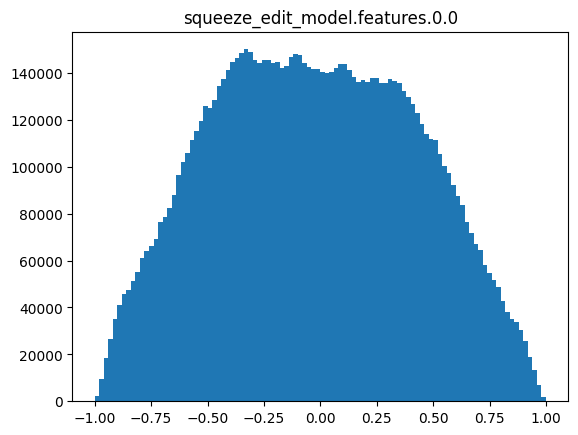

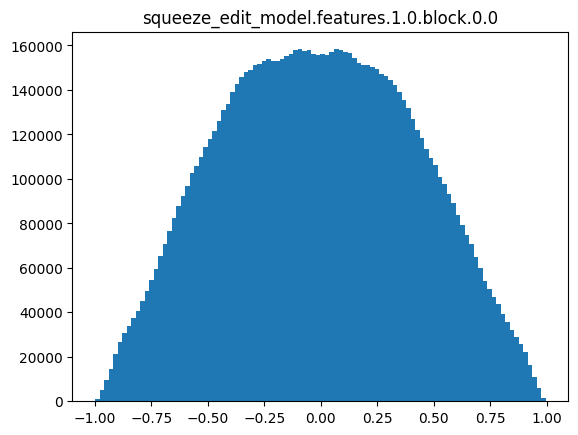

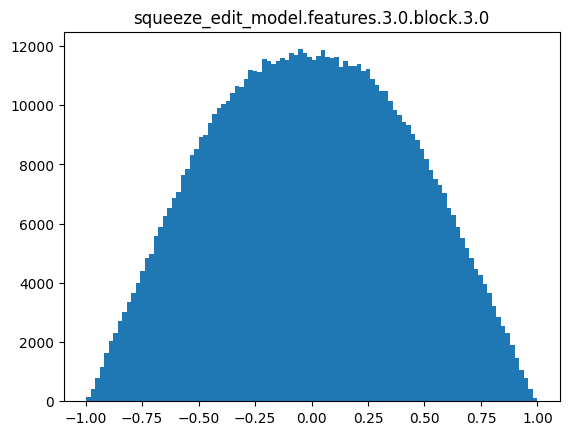

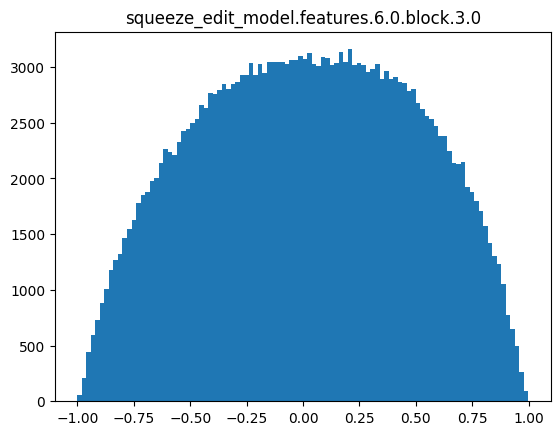

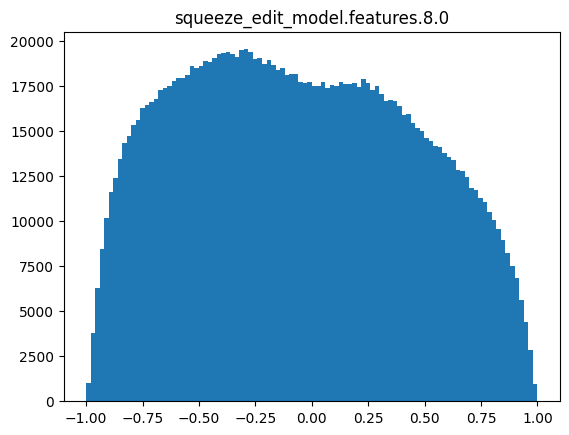

In [14]:
import matplotlib.pyplot as plt

for i, (param, hist) in enumerate(zip(result.layer_names, result.correlation_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Exclude Training

In [15]:
session.exclude_training(
    project.id,
    checkpoint_paths,
    [2, 5],
    DATA_PATH / "excluded_3_and_6.pt",
)

data/TORCH_MilitaryAircraft/excluded_3_and_6.pt

In [16]:
(DATA_PATH / "excluded_3_and_6.pt").is_file()

True

## Zero-Training Optimization & Maintenance (ZTOM)

In [17]:
import torch

def milair_loss_function(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    l = torch.nn.functional.cross_entropy(y_pred, y_true)
    return l.item()

In [18]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = torch.stack([preprocess_image(image_path) for image_path in image_paths], dim=0)
print(input_data.shape)

[PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/TORCH_MilitaryAircraft/stimuli/F4-2.jpg')]
torch.Size([7, 3, 224, 224])


In [19]:
outputs = np.loadtxt(DATA_PATH / "expected_outputs.csv", delimiter=",")
expected_class_indices = torch.tensor(outputs.argmax(axis=1)).cuda()
expected_class_indices

tensor([ 9,  9,  9, 10, 13, 13, 13], device='cuda:0')

In [20]:
from authentrics import ZtomOptimizationOptions

# Optional: tune optimization parameters (defaults are often sufficient)
options = ZtomOptimizationOptions(lower_bound=-0.5, upper_bound=0.5)

# loss_function: callable(model_output) -> float
# can be passed directly as a lambda or normal function
result = session.ztom_analysis(
    project.id,
    checkpoint_paths,
    input_data.cuda(),
    loss_function=lambda y_pred: milair_loss_function(expected_class_indices, y_pred),
    new_checkpoint_path=DATA_PATH / "checkpoint_optimized.pt",
    optimization_options=options,
)

In [21]:
print(result.scaling_factors)
print(result.number_of_inferences)

[-0.013606222410107465, -0.010358974542754617, -0.043434837997266385, 0.2534995515841527, -0.007723472869653082, -0.042428666615657966]
50
